#  Part 1 : Installation YOLOE and tests experiences



####  Local Install (VS Code / VSCodium / Terminal)

```bash
# Step 1: Create a virtual environment (recommended)
python -m venv yoloe_env

# Activate it
# On Linux/Mac:
source yoloe_env/bin/activate
# On Windows:
yoloe_env\Scripts\activate

# Step 2: Install PyTorch with CUDA support
# Visit https://pytorch.org to find the right command for your CUDA version
# Example for CUDA 11.8:
pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118

# Step 3: Install Ultralytics
pip install ultralytics

# Step 4: Optional extras
pip install opencv-python matplotlib pillow

# Step 5: Verify
python -c "from ultralytics import YOLOE; print('YOLOE ready!')"
```

#### VSCodium / VS Code Extension Setup

1. Install VS Code / VSCodium
2. Install extensions:
   - Python (ms-python.python)
   - Jupyter (ms-toolsai.jupyter)
3. Select interpreter: Ctrl+Shift+P → "Python: Select Interpreter"
   → Choose your yoloe_env
4. Open this .ipynb file directly

In [ ]:
# Check GPU availability
# !nvidia-smi

# Install Ultralytics (official YOLOE implementation)
# !pip install ultralytics -q

# Verify installation
import ultralytics
print(f"Ultralytics version: {ultralytics.__version__}")

# For the original THU-MIG implementation (optional, more research-oriented)
# git clone https://github.com/THU-MIG/yoloe.git
# !cd yoloe && pip install -r requirements.txt -q


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.3 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "d:\Aims_project\open-vocabulary-6d-pose-yoloe\venv\Lib\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "d:\Aims_project\open-vocabulary-6d-pose-yoloe\venv\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "d:\Aims_project\open-vocabulary-6d-pose-yoloe\venv\Lib\site-packages\ipykernel\kernelapp.py", line 758, in

AttributeError: _ARRAY_API not found

ImportError: numpy.core.multiarray failed to import

: 

In [ ]:
!nvidia-smi

Thu Apr 23 16:42:38 2026       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 538.18                 Driver Version: 538.18       CUDA Version: 12.2     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                     TCC/WDDM  | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  Quadro M1000M                WDDM  | 00000000:01:00.0 Off |                  N/A |
| N/A    0C    P8              N/A /  21W |      0MiB /  4096MiB |      0%      Default |
|                                         |                      |                  N/A |
+-----------------------------------------+----------------------+--

In [7]:
import sys
import torch

print("=" * 100)
print(f"Python:  {sys.version}")
print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("Running on CPU (slower, but works for inference)")
print("=" * 100)

Python:  3.11.8 (tags/v3.11.8:db85d51, Feb  6 2024, 22:03:32) [MSC v.1937 64 bit (AMD64)]
PyTorch: 2.4.1+cu121
CUDA available: True
GPU: Quadro M1000M
VRAM: 4.3 GB


<a id='4-model-variants'></a>
###   YOLOE Model Variants

### Text/Visual Prompt Models

| Model | Params | GFLOPs | LVIS AP | Speed | Use Case |
|-------|--------|--------|---------|-------|----------|
| `yoloe-v8s-seg-pf` | 11.8M | 42.4 | — | Fastest | Edge devices |
| `yoloe-v8m-seg-pf` | 27.3M | 110.1 | — | Fast | Balanced |
| `yoloe-v8l-seg-pf` | 44.1M | 220.8 | — | Medium | Server |
| `yoloe-11s-seg` | ~10M | — | ~30 AP | Fast | Open-vocab small |
| `yoloe-11l-seg` | ~25M | — | ~35 AP | Medium | Open-vocab large |

- `pf` = Prompt-Free variant
- `seg` = includes segmentation
- `v8` / `11` = backbone version

### 4.3 Which Model to Choose?

- Are you just starting?         → yoloe-v8s (small, fast)
- Need open-vocab with text?     → yoloe-11l-seg (text prompts)
- Want to use reference images?  → yoloe-11l-seg (visual prompts)
- Production deployment?         → yoloe-v8l-seg-pf (prompt-free, fastest)
- COCO-like benchmark?           → yoloe-v8l (fine-tuned on COCO)

In [9]:
# ─────────────────────────────────────────────
# Download and explore YOLOE models
# ─────────────────────────────────────────────
from ultralytics import YOLOE

# Load a small model (auto-downloads weights ~25MB)
# For text/visual prompts:
model = YOLOE("yoloe-11s-seg.pt")

# Inspect the model
print("Model type:", type(model))
print("Model task:", model.task)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,} ({total_params/1e6:.1f}M)")

Model type: <class 'ultralytics.models.yolo.model.YOLOE'>
Model task: segment
Total parameters: 13,710,038 (13.7M)


<a id='5-text-prompts'></a>
## Method1 : Text Prompts

- The Text Encoding Pipeline

-  Prompt Engineering Tips

In [10]:
# ─────────────────────────────────────────────
# TEXT PROMPT INFERENCE
# ─────────────────────────────────────────────
from ultralytics import YOLOE
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import numpy as np
import requests
from io import BytesIO



Remark : 
- text prompt , "  tennis ball " detect with  yoloe-11l-seg.pt but no detection for  yoloe-26l-seg.pt 
- ball ,ball tennis   dectect for yoloe-26l-seg.pt 


image 1/1 d:\Aims_project\open-vocabulary-6d-pose-yoloe\notebooks\test_image.jpg: 448x640 1 ball tennis, 236.5ms
Speed: 14.8ms preprocess, 236.5ms inference, 3.4ms postprocess per image at shape (1, 3, 448, 640)


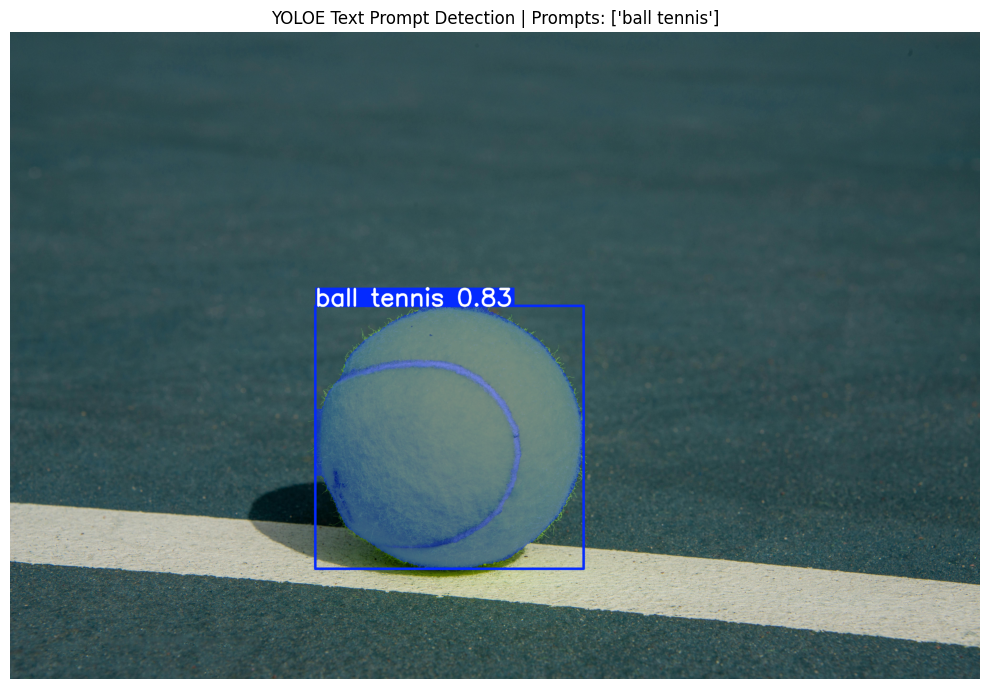

 Detected 1 objects


In [30]:
# Load model
# we use  yoloe-11l-seg.pt and yoloe-26l-seg.pt 
model = YOLOE("yoloe-26l-seg.pt")  # Large model for better accuracy

# Download a sample image
url = "https://images.pexels.com/photos/13025827/pexels-photo-13025827.jpeg" #"https://ultralytics.com/images/bus.jpg"
response = requests.get(url)
img = Image.open(BytesIO(response.content))
img.save("test_image.jpg")

# ── Set text prompts ─────────────────────────
# Define what you want to detect:
text_prompts = ["ball tennis"]  #["bus", "person", "traffic sign"]

# Set the classes using text prompts
model.set_classes(text_prompts, model.get_text_pe(text_prompts))

# ── Run inference ────────────────────────────
results = model.predict(
    "test_image.jpg",
    conf=0.25,        # Confidence threshold (0-1)
    iou=0.45,         # IoU threshold for NMS
    verbose=True
)

# ── Display results ──────────────────────────
result = results[0]
annotated = result.plot()

plt.figure(figsize=(10, 8))
plt.imshow(annotated[:, :, ::-1])  # BGR → RGB
plt.title(f"YOLOE Text Prompt Detection | Prompts: {text_prompts}")
plt.axis('off')
plt.tight_layout()
plt.savefig("yoloe_text_result.png", dpi=300)
plt.show()
print(f" Detected {len(result.boxes)} objects")

In [31]:
# ─────────────────────────────────────────────
# UNDERSTANDING THE RESULTS OBJECT
# ─────────────────────────────────────────────
result = results[0]

print("=" * 60)
print("RESULT OBJECT STRUCTURE")
print("=" * 60)

# Bounding boxes
print("\n Bounding Boxes (xyxy format):")
for i, box in enumerate(result.boxes):
    x1, y1, x2, y2 = box.xyxy[0].tolist()
    conf = box.conf[0].item()
    cls_id = int(box.cls[0].item())
    cls_name = result.names[cls_id]
    print(f"  [{i}] Class: {cls_name:15s} | Conf: {conf:.3f} | "
          f"Box: ({x1:.0f},{y1:.0f}) → ({x2:.0f},{y2:.0f})")
    
# Masks (if available)
if result.masks is not None:
    print(f"\n🎭 Segmentation masks: {result.masks.data.shape}")
    print(f"   Shape: [N_objects, H, W] = {result.masks.data.shape}")

# Image info
print(f"\nImage size: {result.orig_shape}  (H×W)")

RESULT OBJECT STRUCTURE

 Bounding Boxes (xyxy format):
  [0] Class: ball tennis     | Conf: 0.833 | Box: (2317,2084) → (4353,4076)

🎭 Segmentation masks: torch.Size([1, 448, 640])
   Shape: [N_objects, H, W] = torch.Size([1, 448, 640])

Image size: (4912, 7360)  (H×W)


<a id='6-visual-prompts'></a>
## Method2: Image/Visual Prompts

In [37]:
# ─────────────────────────────────────────────
# VISUAL (IMAGE) PROMPT INFERENCE
# ─────────────────────────────────────────────
from ultralytics import YOLOE
from ultralytics.models.yolo.yoloe import YOLOEVPSegPredictor

model = YOLOE("yoloe-26l-seg.pt")

# Provide reference images (visual prompts)
# Each dict: {"cls": class_id, "bboxes": [[x1,y1,x2,y2]]}
# pointing to the reference object within a reference image

url = "https://images.pexels.com/photos/13025827/pexels-photo-13025827.jpeg" #"https://ultralytics.com/images/bus.jpg"
response = requests.get(url)
refer_image = Image.open(BytesIO(response.content))
refer_image.save("test_image.jpg")
test_image  = r"D:\Aims_project\open-vocabulary-6d-pose-yoloe\images\tennis_res.jpg"

# Visual prompts format:
# [{"cls": 0, "bboxes": [[x1, y1, x2, y2]]}]
# where bbox points to the object in the reference image
visual_prompts = {
    "cls": [0],  # Class ID ball
    "bboxes": [[2317,2084, 4353, 4076]]  # Example bbox in the reference image
}

results = model.predict(
    test_image,
    refer_image=refer_image,
    visual_prompts=visual_prompts,
    predictor=YOLOEVPSegPredictor
)

print("Visual prompt inference complete!")
print(f"Found {len(results[0].boxes)} matching objects")

Ultralytics 8.4.37  Python-3.11.8 torch-2.4.1+cu121 CUDA:0 (Quadro M1000M, 4096MiB)
YOLOe-26l-seg summary (fused): 232 layers, 35,437,026 parameters, 2,749,490 gradients, 141.6 GFLOPs

image 1/1 D:\Aims_project\open-vocabulary-6d-pose-yoloe\images\tennis_res.jpg: 640x480 3 object0s, 257.1ms
Speed: 6.5ms preprocess, 257.1ms inference, 5.2ms postprocess per image at shape (1, 3, 640, 480)
Visual prompt inference complete!
Found 3 matching objects


<a id='7-prompt-free'></a>
## Method 3 : Prompt-Free Mode

In prompt-free mode, YOLOE acts like a **regular YOLO** model but with open-vocabulary efficiency.
The model has **learned internal vocabulary** embeddings for common categories.

In [38]:
# ─────────────────────────────────────────────
# PROMPT-FREE INFERENCE (Fastest Mode)
# ─────────────────────────────────────────────
from ultralytics import YOLOE

# Load prompt-free model (note the '-pf' suffix)
model_pf = YOLOE("yoloe-26l-seg-pf.pt")

# No prompts needed — just run!
results = model_pf.predict(
    "test_image.jpg",
    conf=0.25,
    save=True,           # Save annotated image
    save_dir="outputs/"
)

# The model detects whatever is there, using its trained vocabulary
result = results[0]
print(f"Detected {len(result.boxes)} objects")
print("Classes found:", [result.names[int(c)] for c in result.boxes.cls])


image 1/1 d:\Aims_project\open-vocabulary-6d-pose-yoloe\notebooks\test_image.jpg: 448x640 1 curb, 1 outdoor, 1 shadow, 1 trick, 2568.6ms
Speed: 10.0ms preprocess, 2568.6ms inference, 23.4ms postprocess per image at shape (1, 3, 448, 640)
Results saved to D:\Aims_project\open-vocabulary-6d-pose-yoloe\notebooks\outputs
Detected 4 objects
Classes found: ['trick', 'outdoor', 'shadow', 'curb']


<a id='8-results'></a>
## 8. Reading & Interpreting Results

### 8.1 The Results Object — Complete Reference

```
results[0]  ← one result per image
    │
    ├── .boxes          ← Detection boxes
    │     ├── .xyxy     ← [x1, y1, x2, y2] absolute pixels
    │     ├── .xywh     ← [cx, cy, w, h] center format
    │     ├── .xyxyn    ← normalized [0,1] coordinates
    │     ├── .conf     ← confidence score [0,1]
    │     └── .cls      ← class index
    │
    ├── .masks          ← Segmentation masks
    │     ├── .data     ← binary masks [N, H, W]
    │     └── .xy       ← polygon contour points
    │
    ├── .names          ← {0: 'person', 1: 'car', ...}
    ├── .orig_img       ← original image array
    ├── .orig_shape     ← (H, W) of original image
    └── .plot()         ← annotated image (numpy array)
```

### 8.2 Bounding Box Coordinate Systems

```
Image (640×480)
┌─────────────────────────────┐  (0,0)
│                             │
│    ┌──────────┐ ←(x1,y1)   │
│    │          │             │
│    │  Object  │             │
│    │          │             │
│    └──────────┘ ←(x2,y2)   │
│                             │
└─────────────────────────────┘  (640,480)

xyxy:  x1=100, y1=50,  x2=300, y2=200
xywh:  cx=200, cy=125, w=200,  h=150
xyxyn: x1=0.156, y1=0.104, x2=0.469, y2=0.417  (normalized)
```

In [39]:
# ─────────────────────────────────────────────
# FULL RESULT ANALYSIS — Professional Output
# ─────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
from PIL import Image

def analyze_yoloe_results(results, class_names=None, conf_threshold=0.3):
    """
    Comprehensive analysis and visualization of YOLOE results.
    
    Args:
        results: List of YOLOE Result objects
        class_names: Optional override for class names dict
        conf_threshold: Minimum confidence to display
    """
    result = results[0]
    img = result.orig_img[:, :, ::-1]  # BGR → RGB
    H, W = result.orig_shape
    
    # Filter by confidence
    boxes = result.boxes
    keep = boxes.conf >= conf_threshold
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    
    # ── Left: Raw image with manual bboxes ───
    ax = axes[0]
    ax.imshow(img)
    
    colors = plt.cm.Set1(np.linspace(0, 1, 10))
    
    for i, (box, valid) in enumerate(zip(boxes, keep)):
        if not valid:
            continue
        x1, y1, x2, y2 = box.xyxy[0].tolist()
        conf = box.conf[0].item()
        cls_id = int(box.cls[0].item())
        cls_name = (class_names or result.names).get(cls_id, f"class_{cls_id}")
        
        color = colors[cls_id % 10]
        rect = patches.Rectangle(
            (x1, y1), x2-x1, y2-y1,
            linewidth=2, edgecolor=color, facecolor='none'
        )
        ax.add_patch(rect)
        ax.text(x1, y1-5, f"{cls_name} {conf:.2f}",
                color='white', fontsize=9, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.2', facecolor=color, alpha=0.8))
    
    ax.set_title(f"Detections (conf ≥ {conf_threshold})", fontsize=12)
    ax.axis('off')
    
    # ── Right: Statistics ────────────────────
    ax2 = axes[1]
    ax2.axis('off')
    
    stats_text = f"""DETECTION REPORT
{'─' * 35}
Image size:     {W}×{H} px
Total detected: {keep.sum().item()} objects
Conf threshold: {conf_threshold}

DETECTIONS:
"""
    for i, (box, valid) in enumerate(zip(boxes, keep)):
        if not valid:
            continue
        x1, y1, x2, y2 = box.xyxy[0].tolist()
        conf = box.conf[0].item()
        cls_id = int(box.cls[0].item())
        cls_name = (class_names or result.names).get(cls_id, f"class_{cls_id}")
        w, h = x2-x1, y2-y1
        area_pct = (w * h) / (W * H) * 100
        stats_text += f"  [{i+1}] {cls_name}\n"
        stats_text += f"      Confidence: {conf:.3f}\n"
        stats_text += f"      BBox: ({x1:.0f},{y1:.0f})→({x2:.0f},{y2:.0f})\n"
        stats_text += f"      Size: {w:.0f}×{h:.0f} ({area_pct:.1f}% of image)\n\n"
    
    ax2.text(0.05, 0.95, stats_text, transform=ax2.transAxes,
             fontsize=9, verticalalignment='top', fontfamily='monospace',
             bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
    
    plt.suptitle("YOLOE Detection Analysis", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig("yoloe_analysis.png", dpi=150, bbox_inches='tight')
    plt.show()

# Call it:
# analyze_yoloe_results(results, conf_threshold=0.3)

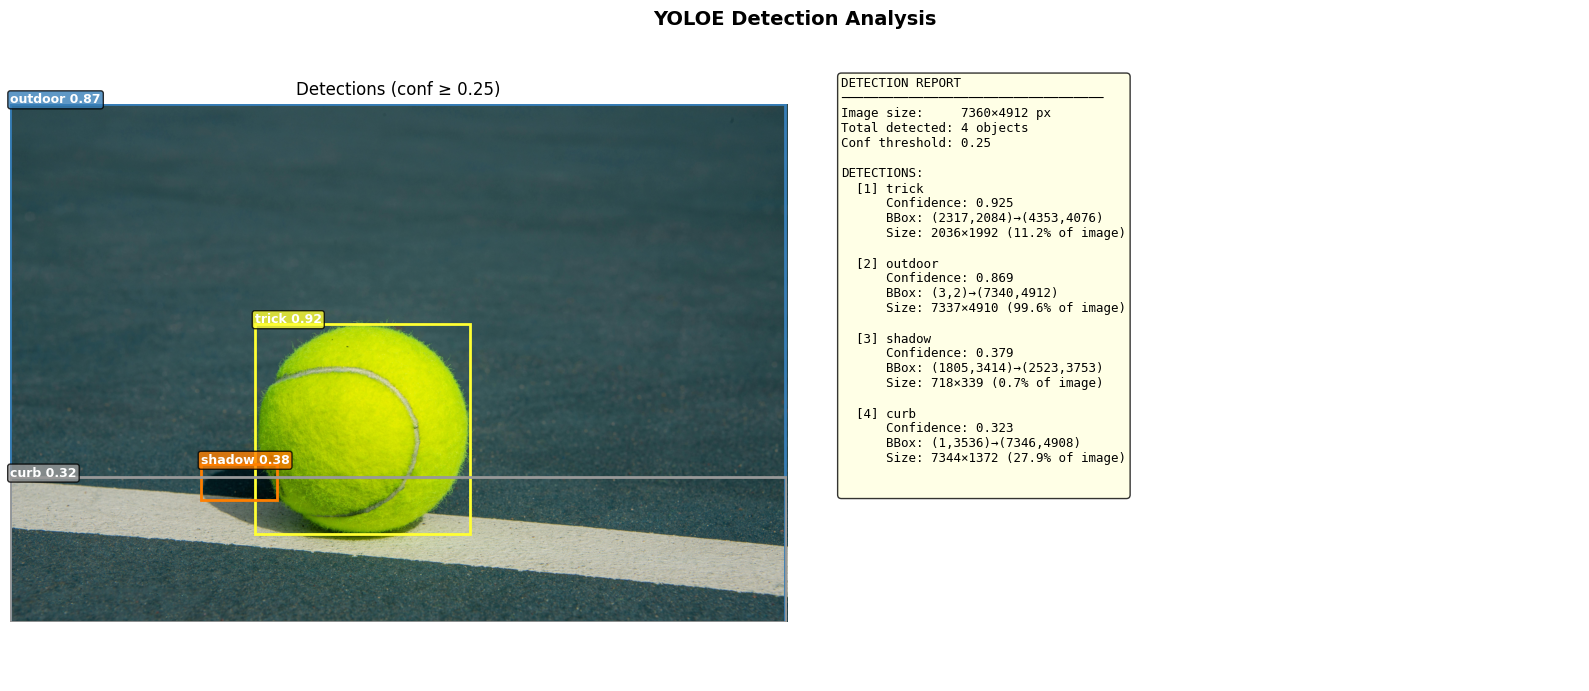

In [40]:
analyze_yoloe_results(results, conf_threshold=0.25)

<a id='9-math-yoloe'></a>
## 9. Mathematics Behind YOLOE

### 9.1 Cosine Similarity — The Core Matching Mechanism

YOLOE matches image features to prompt embeddings using **cosine similarity**:

$$\text{score}(\mathbf{f}, \mathbf{t}) = \frac{\mathbf{f} \cdot \mathbf{t}}{\|\mathbf{f}\| \cdot \|\mathbf{t}\|}$$

Where:
- $\mathbf{f} \in \mathbb{R}^d$ = image region feature vector
- $\mathbf{t} \in \mathbb{R}^d$ = text (or image) prompt embedding
- $d$ = embedding dimension (typically 512 or 768)

Score range: **[-1, +1]** where +1 = perfect match

### 9.2 DFL — Distribution Focal Loss (Bounding Box Regression)

YOLOE uses **DFL** to predict bounding boxes as probability distributions:

Instead of directly predicting `(x1, y1, x2, y2)`, predict the **distribution** of each edge:

$$P(\text{left edge} = k) = \text{softmax}(\mathbf{w}_k)  \quad k \in \{0, 1, ..., 15\}$$

$$\hat{d}_{left} = \sum_{k=0}^{15} k \cdot P(k)$$

This is more flexible than direct regression — it can express **uncertainty** in the prediction.

### 9.3 IoU — Intersection over Union

$$\text{IoU}(A, B) = \frac{|A \cap B|}{|A \cup B|}$$

Used in two places:
1. **NMS** (Non-Maximum Suppression): remove duplicate detections (IoU > 0.45 → remove)
2. **Training loss**: measure how well predicted box matches ground truth

```
Predicted:   ┌──────────┐
             │    ┌─────┼────┐
             │ ∩  │     │   │
             └────┼─────┘   │  ← Ground Truth
                  └─────────┘

IoU = Area(∩) / Area(∪)
```

### 9.4 Training Loss Function

$$\mathcal{L}_{total} = \lambda_1 \mathcal{L}_{cls} + \lambda_2 \mathcal{L}_{bbox} + \lambda_3 \mathcal{L}_{seg}$$

- $\mathcal{L}_{cls}$: Classification loss (VFL — Varifocal Loss)
- $\mathcal{L}_{bbox}$: Box regression (CIoU + DFL)
- $\mathcal{L}_{seg}$: Segmentation (Binary Cross-Entropy per pixel)

### 9.5 Feature Pyramid Network (FPN) — Multi-Scale Detection

$$F_{out}^{l} = \text{Conv}\left(F_{backbone}^{l} + \text{Upsample}(F_{out}^{l+1})\right)$$

This allows detecting objects at **multiple scales** simultaneously:
- Small objects → high-resolution feature maps (P3: 80×80)
- Large objects → low-resolution feature maps (P5: 20×20)

In [ ]:
# ─────────────────────────────────────────────
# MATH DEMO: Cosine Similarity
# ─────────────────────────────────────────────
import torch
import torch.nn.functional as F
import numpy as np

def cosine_similarity_demo():
    """Demonstrate how YOLOE matches features to prompts."""
    d = 512  # embedding dimension
    
    # Simulate text embeddings (as if from CLIP)
    text_dog = torch.randn(d)      # embedding for "dog"
    text_cat = torch.randn(d)      # embedding for "cat"
    text_car = torch.randn(d)      # embedding for "car"
    
    # Simulate an image region feature (should be close to "dog")
    # In reality, this comes from the backbone CNN
    image_feature = text_dog + 0.1 * torch.randn(d)  # nearly = dog embedding
    
    # Compute cosine similarities
    sim_dog = F.cosine_similarity(image_feature.unsqueeze(0), text_dog.unsqueeze(0))
    sim_cat = F.cosine_similarity(image_feature.unsqueeze(0), text_cat.unsqueeze(0))
    sim_car = F.cosine_similarity(image_feature.unsqueeze(0), text_car.unsqueeze(0))
    
    print("=" * 40)
    print("Cosine Similarity Demo")
    print("=" * 40)
    print(f"Image region vs 'dog': {sim_dog.item():.4f}  ← highest!")
    print(f"Image region vs 'cat': {sim_cat.item():.4f}")
    print(f"Image region vs 'car': {sim_car.item():.4f}")
    print(f"\nConclusion: Model detects 'dog' (highest score)")

cosine_similarity_demo()

# ─────────────────────────────────────────────
# MATH DEMO: IoU Calculation
# ─────────────────────────────────────────────
def compute_iou(boxA, boxB):
    """
    Compute Intersection over Union (IoU) between two boxes.
    Args:
        boxA, boxB: [x1, y1, x2, y2] format
    Returns:
        IoU score in [0, 1]
    """
    # Intersection coordinates
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])
    
    # Intersection area
    interArea = max(0, xB - xA) * max(0, yB - yA)
    
    # Individual areas
    areaA = (boxA[2] - boxA[0]) * (boxA[3] - boxA[1])
    areaB = (boxB[2] - boxB[0]) * (boxB[3] - boxB[1])
    
    # Union area
    unionArea = areaA + areaB - interArea
    
    return interArea / unionArea if unionArea > 0 else 0.0

# Test
pred  = [100, 50, 300, 200]   # predicted box
gt    = [120, 60, 320, 210]   # ground truth box
iou = compute_iou(pred, gt)
print(f"\nIoU between predicted and ground truth: {iou:.4f}")
print(f"Interpretation: {'Good match (>0.5)' if iou > 0.5 else 'Poor match (<0.5)'}")

<a id='10-exercises-yoloe'></a>
## 🧪  Exercises — YOLOE

### Exercise 1 — Beginner: Change the Prompts

In [ ]:
# ═══════════════════════════════════════
# EXERCISE 2 — INTERMEDIATE
# Implement Non-Maximum Suppression (NMS) from scratch
# ═══════════════════════════════════════

def nms_from_scratch(boxes, scores, iou_threshold=0.5):
    """
    Implement NMS to remove duplicate detections.
    
    Args:
        boxes: list of [x1,y1,x2,y2]
        scores: confidence scores
        iou_threshold: boxes with IoU > this are suppressed
    
    Returns:
        indices of kept boxes
    """
    # TODO: Complete this implementation!
    # Hint:
    # 1. Sort boxes by score (highest first)
    # 2. Keep the highest-score box
    # 3. Remove all boxes with IoU > threshold vs kept box
    # 4. Repeat until no boxes left
    
    order = sorted(range(len(scores)), key=lambda i: scores[i], reverse=True)
    kept = []
    
    while order:
        # Keep the best remaining box
        best = order[0]
        kept.append(best)
        order = order[1:]
        
        # Remove overlapping boxes
        # TODO: Compute IoU between 'best' and all boxes in 'order'
        #       and remove those with IoU > iou_threshold
        order = [i for i in order 
                 if compute_iou(boxes[best], boxes[i]) <= iou_threshold]  # ← fill this
    
    return kept

# Test your NMS
test_boxes = [
    [100, 100, 300, 300],  # big box
    [110, 110, 310, 310],  # overlaps with box 0 (high IoU)
    [400, 400, 600, 600],  # far away (low IoU)
]
test_scores = [0.9, 0.8, 0.7]

kept = nms_from_scratch(test_boxes, test_scores, iou_threshold=0.5)
print(f"Boxes kept after NMS: {kept}")
print("Expected: [0, 2]  (box 1 should be removed, too similar to box 0)")

In [ ]:
# ═══════════════════════════════════════
# EXERCISE 3 — ADVANCED
# Fine-tune YOLOE on a custom dataset
# ═══════════════════════════════════════

# This example shows the structure — you need a labeled dataset!
# Dataset format: YOLO format (one .txt per image with bbox labels)

# data.yaml structure:
DATA_YAML = """
# data.yaml
path: /path/to/my_dataset
train: images/train
val: images/val

nc: 3  # number of classes
names: ['cat', 'dog', 'bird']  # your class names
"""

print("Dataset YAML format:")
print(DATA_YAML)

# Training command (run this after creating data.yaml):
TRAIN_CODE = """
from ultralytics import YOLOE

model = YOLOE("yoloe-v8s-seg.pt")  # start from pretrained

# Fine-tune on custom dataset
results = model.train(
    data="data.yaml",
    epochs=50,
    imgsz=640,
    batch=16,
    lr0=0.001,
    device=0,        # GPU 0
    project="my_yoloe_run",
    name="experiment_1"
)
"""
print("Training code:")
print(TRAIN_CODE)

# CHALLENGE: Can you write a script that:
# 1. Downloads the COCO128 sample dataset
# 2. Fine-tunes YOLOE-small on it for 5 epochs
# 3. Evaluates and plots the mAP curve?

---
# PART 2 — Any6D: Model-Free 6D Pose Estimation

---

<a id='11-pose-estimation'></a>
## 11. What is Pose Estimation?

### From 2D to 6D: The Problem Space


- 2D Detection (YOLOE):     Where in the IMAGE is the object?
                          → Bounding box (x, y, w, h)

- 2D Pose (Keypoints):      Where are the body joints in the image?
                          → 17 keypoints (x, y) each

- 3D Pose:                  Where is the object in 3D SPACE?
                          → (X, Y, Z) in meters

- 6D Pose (Any6D):          Where AND how oriented is it in 3D space?
                          → Translation (X, Y, Z) + Rotation (R: 3×3 matrix)


### The 6 Degrees of Freedom (6-DoF)

```
TRANSLATION (3 DoF):          ROTATION (3 DoF):
                               
  Z (depth) ↑                  Roll (rotate around Z)
            │    Y (up)        Pitch (rotate around X)
            │   ╱              Yaw   (rotate around Y)
            │  ╱
            │ ╱
            └────────► X (right)

Object pose = where it is (XYZ) + how it's rotated (RPY or R matrix)
```

### Why 6D Pose Matters

```
Application          What 6D pose enables
─────────────────────────────────────────────────
Robot manipulation   Grasp object at correct angle
AR/VR               Overlay virtual objects on real world
Autonomous driving  Predict 3D position of other cars
Quality control     Check assembly orientation
Medical robotics    Precise instrument placement
```

### Traditional vs. Any6D Approach

```
TRADITIONAL (CAD-based):
  Need 3D CAD model of object → train model on it → estimate pose
  Problem: CAD models hard to obtain, doesn't generalize

ANY6D (Model-free):
  Need only 1-2 reference images → automatically estimate pose
  Works on ANY novel object without 3D model!
```

<a id='12-any6d-architecture'></a>
## 12. Any6D Architecture Deep Dive

### 12.1 The Any6D Pipeline

Any6D (CVPR 2025) is a **model-free 6D pose estimation** system that requires only reference images, no 3D CAD models.

```
┌─────────────────────────────────────────────────────────────────────┐
│                        ANY6D PIPELINE                               │
│                                                                     │
│  Input:                                                             │
│  ┌──────────────┐   ┌─────────────────┐                            │
│  │ Reference    │   │  Query Image    │                            │
│  │ Image(s) of  │   │  (scene with    │                            │
│  │ the object   │   │  the object)    │                            │
│  └──────┬───────┘   └────────┬────────┘                            │
│         │                    │                                      │
│  STEP 1: Object Detection & Segmentation                            │
│         │                    │                                      │
│         └──────────┬─────────┘                                      │
│                    ▼                                                 │
│            ┌───────────────┐                                        │
│            │  SAM-2        │  ← Segment Anything Model              │
│            │  (Segmentation│    Extracts object masks               │
│            └───────┬───────┘                                        │
│                    │                                                 │
│  STEP 2: 3D Reconstruction from Reference Image                     │
│                    ▼                                                 │
│            ┌───────────────┐                                        │
│            │  InstantMesh  │  ← Generates 3D mesh from 2D image    │
│            │  (3D Recon.)  │    (single-view 3D reconstruction)    │
│            └───────┬───────┘                                        │
│                    │                                                 │
│  STEP 3: 6D Pose Estimation                                         │
│                    ▼                                                 │
│            ┌───────────────┐                                        │
│            │ FoundationPose│  ← Estimates 6DoF pose using          │
│            │ (Pose Est.)   │    3D mesh + 2D observations          │
│            └───────┬───────┘                                        │
│                    │                                                 │
│  Output: 6D Pose = [R | t] (4×4 transformation matrix)             │
└─────────────────────────────────────────────────────────────────────┘
```

### 12.2 Component 1: SAM-2 (Segment Anything Model)

SAM-2 segments any object from a bounding box or point prompt:

```
Input: Image + Prompt (bbox or point)
             ↓
       Image Encoder (ViT-H)    →  Image Embedding
       Prompt Encoder           →  Prompt Embedding
             ↓
       Mask Decoder (2 layers)
             ↓
Output: Binary Mask (H × W)
```

### 12.3 Component 2: InstantMesh (3D Reconstruction)

InstantMesh creates a 3D mesh from a single reference image:

```
Input: Single 2D Image of object
             ↓
       Diffusion Model  →  Multi-view synthesis
       (generates 6 views at different angles)
             ↓
       LRM (Large Reconstruction Model)
       (transforms multi-view images → 3D representation)
             ↓
Output: 3D Mesh (.obj format)
```

### 12.4 Component 3: FoundationPose (6D Pose)

FoundationPose estimates the 6D pose using the reconstructed 3D mesh:

```
Input:
  - Query RGB image
  - Depth image (optional)
  - Object mask (from SAM-2)
  - 3D mesh (from InstantMesh)
  - Camera intrinsics K

Process:
  1. Pose hypotheses sampling (random rotations/translations)
  2. Render hypothesis → compare with observed image
  3. Pose refinement network

Output:
  - Rotation matrix R (3×3)
  - Translation vector t (3×1)
  → Full pose [R|t] (3×4 or 4×4 homogeneous)
```

<a id='13-any6d-install'></a>
## 13. Any6D Installation & Setup

### 13.1 Requirements

```
Hardware requirements:
- GPU: NVIDIA GPU with ≥16GB VRAM (recommended: RTX 3090/4090 or A100)
- RAM: ≥32GB
- Storage: ≥20GB for models

Software:
- CUDA 11.8 or 12.x
- Python 3.9+
- Docker (recommended for reproducibility)
```

### 13.2 Installation Steps

In [ ]:
# ─────────────────────────────────────────────
# ANY6D INSTALLATION
# Option 1: Docker (RECOMMENDED — easiest)
# ─────────────────────────────────────────────

docker_commands = """
# Step 1: Clone the repository
git clone https://github.com/taeyeopl/Any6D.git
cd Any6D

# Step 2: Build Docker image
docker build -t any6d:latest .

# Step 3: Run container with GPU support
docker run --gpus all -it \\
    -v $(pwd):/workspace \\
    -v /path/to/data:/data \\
    any6d:latest

# Step 4: Inside container, run the demo
cd /workspace
python run_demo.py \\
    --ref_image demo_data/ref_image.png \\
    --query_image demo_data/query_image.png
"""

print("Docker Installation Commands:")
print(docker_commands)

In [ ]:
# ─────────────────────────────────────────────
# ANY6D INSTALLATION
# Option 2: Manual (for development)
# ─────────────────────────────────────────────

manual_install = """
# Step 1: Clone
git clone https://github.com/taeyeopl/Any6D.git
cd Any6D

# Step 2: Install main dependencies
pip install torch==2.0.1 torchvision==0.15.2 --index-url https://download.pytorch.org/whl/cu118
pip install -r requirements.txt

# Step 3: Install SAM-2
cd sam2
pip install -e .
cd ..

# Step 4: Install InstantMesh
cd instantmesh
pip install -e .
cd ..

# Step 5: Install FoundationPose
cd foundationpose
pip install -e .
cd ..

# Step 6: Download pretrained models
# (see README for model download links)
python download_models.py
"""

print("Manual Installation:")
print(manual_install)

<a id='14-pipeline'></a>
## 14. Pipeline: 2D → 3D → 6D

### 14.1 Step-by-Step with Code

```
STEP 1: You have a 2D image of a scene
STEP 2: YOLOE detects the object → bounding box
STEP 3: SAM-2 segments the object → binary mask
STEP 4: InstantMesh builds a 3D model from reference image
STEP 5: FoundationPose estimates 6D pose
STEP 6: Output: 4×4 transformation matrix
```

In [ ]:
# ─────────────────────────────────────────────
# ANY6D DEMO — Conceptual walkthrough
# (Actual execution requires GPU + full setup)
# ─────────────────────────────────────────────
import numpy as np

# ─────────────────────────────────────────────
# STEP 1: Detect object in query image (YOLOE)
# ─────────────────────────────────────────────
def detect_object_yoloe(query_image_path, text_prompt):
    """
    Use YOLOE to detect the target object and get bounding box.
    Returns: bbox [x1, y1, x2, y2]
    """
    from ultralytics import YOLOE
    model = YOLOE("yoloe-11l-seg.pt")
    model.set_classes([text_prompt], model.get_text_pe([text_prompt]))
    results = model.predict(query_image_path, conf=0.3)
    
    if len(results[0].boxes) == 0:
        raise ValueError(f"Object '{text_prompt}' not found in image!")
    
    # Take highest-confidence detection
    best_box = results[0].boxes[results[0].boxes.conf.argmax()]
    bbox = best_box.xyxy[0].tolist()
    mask = results[0].masks.data[results[0].boxes.conf.argmax()].numpy() if results[0].masks else None
    
    return bbox, mask

print("Step 1: YOLOE detection function defined")
print("  Returns: bounding box [x1, y1, x2, y2] and segmentation mask")

In [ ]:
# ─────────────────────────────────────────────
# STEP 2: 3D Reconstruction (InstantMesh)
# ─────────────────────────────────────────────

def reconstruct_3d_from_reference(ref_image_path, object_mask=None):
    """
    Reconstruct a 3D mesh from a single reference image.
    Uses InstantMesh (requires ~16GB VRAM for full model).
    
    Args:
        ref_image_path: Path to reference image
        object_mask: Optional mask to isolate the object
    Returns:
        Path to reconstructed 3D mesh (.obj file)
    """
    # In practice, this calls the InstantMesh pipeline:
    # 1. Preprocess: background removal using the mask
    # 2. Multi-view diffusion: generate 6 views
    # 3. LRM reconstruction: build 3D mesh
    
    print("[InstantMesh] Preprocessing image...")
    print("[InstantMesh] Running multi-view diffusion (generates 6 views)...")
    print("[InstantMesh] Reconstructing 3D mesh with LRM...")
    print("[InstantMesh] Mesh saved to: output/mesh.obj")
    
    return "output/mesh.obj"

print("Step 2: 3D reconstruction function defined")

# ─────────────────────────────────────────────
# STEP 3: Pose Estimation (FoundationPose)
# ─────────────────────────────────────────────

def estimate_6d_pose(query_image, query_mask, mesh_path, camera_K):
    """
    Estimate 6D pose using FoundationPose.
    
    Args:
        query_image: RGB image (H×W×3)
        query_mask: Binary mask (H×W)
        mesh_path: Path to 3D mesh
        camera_K: Camera intrinsic matrix (3×3)
    Returns:
        pose: 4×4 transformation matrix [R|t; 0|1]
    """
    print("[FoundationPose] Sampling pose hypotheses...")
    print("[FoundationPose] Rendering and scoring hypotheses...")
    print("[FoundationPose] Refining best pose...")
    
    # Returns 4×4 pose matrix
    # For demo, return identity (no rotation, no translation)
    pose = np.eye(4)
    return pose

print("Step 3: 6D pose estimation function defined")

In [ ]:
# ─────────────────────────────────────────────
# FULL ANY6D PIPELINE — Orchestration
# ─────────────────────────────────────────────

def any6d_full_pipeline(
    ref_image_path,
    query_image_path,
    object_description,
    camera_intrinsics
):
    """
    Complete Any6D pipeline: reference image + query image → 6D pose
    
    Args:
        ref_image_path:     Path to reference image of the object
        query_image_path:   Path to query scene image
        object_description: Text description for YOLOE (e.g., 'blue mug')
        camera_intrinsics:  3×3 camera matrix K
    
    Returns:
        pose_4x4: 4×4 transformation matrix
    """
    print(f"\n{'='*50}")
    print(f"ANY6D PIPELINE")
    print(f"{'='*50}")
    print(f"Reference: {ref_image_path}")
    print(f"Query:     {query_image_path}")
    print(f"Object:    {object_description}")
    print()
    
    # ── Stage 1: Detect in query image ──────────
    print("[Stage 1/3] Object detection (YOLOE)...")
    # bbox, query_mask = detect_object_yoloe(query_image_path, object_description)
    bbox = [100, 50, 350, 300]  # Demo values
    print(f"  → Found object at bbox: {bbox}")
    
    # ── Stage 2: 3D reconstruction from reference ─
    print("[Stage 2/3] 3D reconstruction (InstantMesh)...")
    # mesh_path = reconstruct_3d_from_reference(ref_image_path)
    mesh_path = "output/mesh.obj"
    print(f"  → 3D mesh saved: {mesh_path}")
    
    # ── Stage 3: Pose estimation ─────────────────
    print("[Stage 3/3] 6D pose estimation (FoundationPose)...")
    # pose = estimate_6d_pose(query_image, query_mask, mesh_path, camera_intrinsics)
    pose = np.array([
        [0.866, -0.5,   0,    0.12],   # Rotation + Translation
        [0.5,    0.866, 0,    0.05],
        [0,      0,     1.0, -0.30],
        [0,      0,     0,    1.0 ]    # Homogeneous row
    ])
    
    print(f"\n✅ 6D Pose Estimated!")
    print(f"Pose matrix [R|t]:")
    print(pose)
    
    return pose

# Demo camera intrinsics (typical RGB-D camera)
K = np.array([
    [614.0,   0.0, 320.0],  # fx, 0, cx
    [  0.0, 614.0, 240.0],  # 0, fy, cy
    [  0.0,   0.0,   1.0],  # 0,  0,  1
])

# Run the pipeline
pose = any6d_full_pipeline(
    ref_image_path="ref_mug.jpg",
    query_image_path="scene.jpg",
    object_description="blue coffee mug",
    camera_intrinsics=K
)

<a id='15-math-any6d'></a>
## 15. Mathematics: Geometry & Deep Learning Behind Any6D

### 15.1 Camera Model — How 3D Becomes 2D

The **pinhole camera model** projects 3D world points to 2D image pixels:

$$\mathbf{p} = K [R | \mathbf{t}] \mathbf{P}_w$$

In expanded form:

$$\begin{pmatrix} u \\ v \\ 1 \end{pmatrix} = \frac{1}{Z} \underbrace{\begin{pmatrix} f_x & 0 & c_x \\ 0 & f_y & c_y \\ 0 & 0 & 1 \end{pmatrix}}_{K: \text{Intrinsic Matrix}} \begin{pmatrix} X_c \\ Y_c \\ Z_c \end{pmatrix}$$

Where:
- $(u, v)$ = pixel coordinates in the image
- $(X_c, Y_c, Z_c)$ = 3D point in **camera** frame (meters)
- $f_x, f_y$ = focal lengths in pixels (typically ~600 for RGB-D cameras)
- $c_x, c_y$ = principal point (image center, e.g., 320, 240 for 640×480)
- $Z_c$ = depth of the point

### 15.2 The Pose Matrix — Full 6D Representation

$$T = \begin{bmatrix} R & \mathbf{t} \\ \mathbf{0}^T & 1 \end{bmatrix} \in \mathbb{R}^{4 \times 4}$$

$$R = \begin{bmatrix} r_{11} & r_{12} & r_{13} \\ r_{21} & r_{22} & r_{23} \\ r_{31} & r_{32} & r_{33} \end{bmatrix} \in SO(3), \quad \mathbf{t} = \begin{pmatrix} t_x \\ t_y \\ t_z \end{pmatrix} \in \mathbb{R}^3$$

Properties of a valid rotation matrix:
- $R^T R = I$ (orthogonal)
- $\det(R) = +1$ (proper rotation)

### 15.3 Rotation Representations

| Representation | Size | Pros | Cons |
|---------------|------|------|------|
| Matrix R | 3×3 = 9 values | Complete, no singularity | Redundant, hard to learn |
| Euler angles (RPY) | 3 values | Intuitive | Gimbal lock |
| Quaternion q | 4 values | Compact, smooth | Non-intuitive |
| Axis-angle | 3 values | Compact | Discontinuous |
| 6D rotation | 6 values | Best for learning | New representation |

### 15.4 Backprojection: 2D Pixel → 3D Point

Given pixel $(u, v)$ and depth $Z$ (from depth camera):

$$X_c = \frac{(u - c_x) \cdot Z}{f_x}, \quad Y_c = \frac{(v - c_y) \cdot Z}{f_y}, \quad Z_c = Z$$

This is the **inverse** of the projection — used to get 3D point clouds from depth images.

### 15.5 Pose Scoring in FoundationPose

FoundationPose scores pose hypotheses by rendering the mesh at each hypothesis and computing:

$$\text{score}(T_i) = \frac{1}{|\Omega|} \sum_{p \in \Omega} \text{sim}(I_{obs}(p), I_{render}(p; T_i))$$

Where:
- $T_i$ = pose hypothesis $i$
- $I_{obs}$ = observed image
- $I_{render}(\cdot; T_i)$ = rendered image at pose $T_i$
- $\text{sim}$ = feature similarity (learned by neural network)
- $\Omega$ = set of pixels within the object mask

In [ ]:
# ─────────────────────────────────────────────
# MATH DEMO: Camera Projection & Backprojection
# ─────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def project_3d_to_2d(point_3d, K, R, t):
    """
    Project a 3D world point to 2D image coordinates.
    
    Args:
        point_3d: [X, Y, Z] in world frame
        K: 3×3 camera intrinsic matrix
        R: 3×3 rotation matrix
        t: [tx, ty, tz] translation vector
    Returns:
        [u, v] pixel coordinates
    """
    # Transform from world to camera frame
    P_world = np.array(point_3d)
    P_cam = R @ P_world + t          # [X_c, Y_c, Z_c]
    
    # Perspective projection
    Z = P_cam[2]
    u = (P_cam[0] * K[0,0] / Z) + K[0,2]  # u = fx*Xc/Zc + cx
    v = (P_cam[1] * K[1,1] / Z) + K[1,2]  # v = fy*Yc/Zc + cy
    
    return np.array([u, v]), P_cam

def backproject_2d_to_3d(pixel, depth, K):
    """
    Convert pixel + depth to 3D point in camera frame.
    
    Args:
        pixel: [u, v] pixel coordinates
        depth: Z value in meters
        K: 3×3 camera intrinsic matrix
    Returns:
        [X, Y, Z] in camera frame
    """
    u, v = pixel
    X = (u - K[0,2]) * depth / K[0,0]  # X_c = (u-cx)*Z/fx
    Y = (v - K[1,2]) * depth / K[1,1]  # Y_c = (v-cy)*Z/fy
    Z = depth
    return np.array([X, Y, Z])

# Camera intrinsics (typical RGB-D camera like RealSense)
K = np.array([
    [614.0,   0.0, 320.0],
    [  0.0, 614.0, 240.0],
    [  0.0,   0.0,   1.0]
])

# Simple rotation: 30° around Y axis
angle = np.radians(30)
R = np.array([
    [ np.cos(angle), 0, np.sin(angle)],
    [             0, 1,             0],
    [-np.sin(angle), 0, np.cos(angle)]
])
t = np.array([0.0, 0.0, 1.0])  # 1 meter in front of camera

# Project a 3D object corner
point_world = [0.1, 0.05, 0.0]  # object corner at 10cm, 5cm from origin
pixel_2d, point_cam = project_3d_to_2d(point_world, K, R, t)

print("=" * 50)
print("PROJECTION DEMO")
print("=" * 50)
print(f"3D World Point:  {point_world}")
print(f"Camera Frame:    {point_cam.round(3)}")
print(f"2D Pixel:        u={pixel_2d[0]:.1f}, v={pixel_2d[1]:.1f}")

# Backproject
depth = point_cam[2]
recovered_3d = backproject_2d_to_3d(pixel_2d, depth, K)
print(f"\nBACKPROJECTION (2D + depth → 3D camera frame):")
print(f"Recovered 3D:    {recovered_3d.round(3)}")
print(f"Original cam:    {point_cam.round(3)}")
print(f"Match: {np.allclose(recovered_3d, point_cam, atol=1e-4)}")

In [ ]:
# ─────────────────────────────────────────────
# MATH DEMO: Rotation Matrix Operations
# ─────────────────────────────────────────────
import numpy as np

def euler_to_rotation_matrix(roll, pitch, yaw):
    """Convert Euler angles (radians) to 3×3 rotation matrix."""
    # Roll (rotation around X)
    Rx = np.array([
        [1,           0,            0],
        [0, np.cos(roll), -np.sin(roll)],
        [0, np.sin(roll),  np.cos(roll)]
    ])
    # Pitch (rotation around Y)
    Ry = np.array([
        [ np.cos(pitch), 0, np.sin(pitch)],
        [             0, 1,             0],
        [-np.sin(pitch), 0, np.cos(pitch)]
    ])
    # Yaw (rotation around Z)
    Rz = np.array([
        [np.cos(yaw), -np.sin(yaw), 0],
        [np.sin(yaw),  np.cos(yaw), 0],
        [          0,            0, 1]
    ])
    return Rz @ Ry @ Rx

def rotation_matrix_to_quaternion(R):
    """Convert 3×3 rotation matrix to quaternion [w, x, y, z]."""
    trace = R[0,0] + R[1,1] + R[2,2]
    if trace > 0:
        s = 0.5 / np.sqrt(trace + 1.0)
        w = 0.25 / s
        x = (R[2,1] - R[1,2]) * s
        y = (R[0,2] - R[2,0]) * s
        z = (R[1,0] - R[0,1]) * s
    else:
        raise NotImplementedError("Handle other cases for production use")
    return np.array([w, x, y, z])

# Example: 45° rotation around Z (yaw)
R = euler_to_rotation_matrix(roll=0, pitch=0, yaw=np.radians(45))
q = rotation_matrix_to_quaternion(R)

print("=" * 50)
print("ROTATION REPRESENTATIONS")
print("=" * 50)
print("Euler: roll=0°, pitch=0°, yaw=45°")
print(f"\nRotation Matrix R:")
print(R.round(4))
print(f"\nOrthogonality check (R^T @ R = I):")
print((R.T @ R).round(6))
print(f"\nDeterminant (should be +1): {np.linalg.det(R):.6f}")
print(f"\nQuaternion [w,x,y,z]: {q.round(4)}")
print(f"Quaternion norm (should be 1): {np.linalg.norm(q):.6f}")

In [ ]:
# ─────────────────────────────────────────────
# MATH DEMO: Point Cloud from Depth Image
# ─────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt

def depth_image_to_pointcloud(depth_image, K, mask=None):
    """
    Convert a depth image to a 3D point cloud.
    This is fundamental to how Any6D processes RGBD input.
    
    Args:
        depth_image: (H, W) array, depth in meters
        K: 3×3 camera intrinsic matrix
        mask: Optional binary mask to select object pixels only
    Returns:
        points: (N, 3) array of 3D points in camera frame
    """
    H, W = depth_image.shape
    fx, fy = K[0,0], K[1,1]
    cx, cy = K[0,2], K[1,2]
    
    # Create pixel coordinate grids
    u = np.arange(W)  # [0, 1, ..., W-1]
    v = np.arange(H)  # [0, 1, ..., H-1]
    uu, vv = np.meshgrid(u, v)  # (H, W) grids
    
    Z = depth_image  # (H, W)
    
    # Backproject all pixels
    X = (uu - cx) * Z / fx   # (H, W)
    Y = (vv - cy) * Z / fy   # (H, W)
    
    # Stack to (H, W, 3)
    points_3d = np.stack([X, Y, Z], axis=-1)  # (H, W, 3)
    
    # Apply mask if provided
    if mask is not None:
        valid = (mask > 0) & (Z > 0)
    else:
        valid = Z > 0
    
    return points_3d[valid]  # (N, 3)

# Simulate a depth image of a flat object
H, W = 240, 320
K = np.array([[400, 0, 160], [0, 400, 120], [0, 0, 1]], dtype=float)

# Fake depth: object at 0.5m in center, background at 1m
depth = np.ones((H, W)) * 1.0
depth[80:160, 100:220] = 0.5  # object region

# Object mask
mask = np.zeros((H, W))
mask[80:160, 100:220] = 1

# Generate point cloud
points = depth_image_to_pointcloud(depth, K, mask)

# Visualize
fig = plt.figure(figsize=(12, 5))

ax1 = fig.add_subplot(121)
ax1.imshow(depth, cmap='viridis')
ax1.set_title('Depth Image')
ax1.set_xlabel('u (pixels)')
ax1.set_ylabel('v (pixels)')
plt.colorbar(ax1.images[0], ax=ax1, label='Depth (m)')

ax2 = fig.add_subplot(122, projection='3d')
ax2.scatter(points[::5,0], points[::5,1], points[::5,2],
            c=points[::5,2], cmap='plasma', s=1)
ax2.set_xlabel('X (m)')
ax2.set_ylabel('Y (m)')
ax2.set_zlabel('Z (m)')
ax2.set_title(f'3D Point Cloud ({len(points)} points)')

plt.tight_layout()
plt.savefig('pointcloud_demo.png', dpi=120)
plt.show()

print(f"Point cloud shape: {points.shape}")
print(f"X range: [{points[:,0].min():.3f}, {points[:,0].max():.3f}] m")
print(f"Y range: [{points[:,1].min():.3f}, {points[:,1].max():.3f}] m")
print(f"Z range: [{points[:,2].min():.3f}, {points[:,2].max():.3f}] m")

<a id='16-working-any6d'></a>
## 16. Working with Any6D

### 16.1 Running the Demo (After Installation)

In [ ]:
# ─────────────────────────────────────────────
# ANY6D DEMO — Shell commands for running
# (Execute in terminal after Docker setup)
# ─────────────────────────────────────────────

demo_script = """
# Inside the Docker container:
cd /workspace

# Run with demo data (provided in repo)
python run_demo.py \\
    --ref_image ./demo_data/ref_image.png \\
    --query_image ./demo_data/query_image.png \\
    --output_dir ./results

# For custom images:
python run_demo.py \\
    --ref_image /path/to/your/reference.jpg \\
    --query_image /path/to/your/scene.jpg \\
    --output_dir ./my_results
"""

print("Any6D Demo Commands:")
print(demo_script)

# Output files you'll get:
print("Expected outputs in ./results/:")
print("  - pose_matrix.npy    ← 4×4 transformation matrix")
print("  - visualization.png  ← pose visualized on image")
print("  - mesh.obj           ← reconstructed 3D mesh")
print("  - axes_projection.png← coordinate axes drawn on scene")

In [ ]:
# ─────────────────────────────────────────────
# VISUALIZING 6D POSE ON AN IMAGE
# (Draw coordinate axes to show orientation)
# ─────────────────────────────────────────────
import numpy as np
import cv2
import matplotlib.pyplot as plt

def draw_pose_axes(image, pose_4x4, K, axis_length=0.05):
    """
    Draw 3D coordinate axes on the image to visualize the pose.
    Red=X, Green=Y, Blue=Z (RGB = XYZ convention)
    
    Args:
        image: HxWx3 RGB image
        pose_4x4: 4×4 transformation matrix (object pose in camera frame)
        K: 3×3 camera intrinsic matrix
        axis_length: Length of each axis in meters
    Returns:
        image with axes drawn
    """
    img = image.copy()
    R = pose_4x4[:3, :3]
    t = pose_4x4[:3, 3]
    
    # Define axis endpoints in object frame
    origin = np.array([0, 0, 0])
    x_axis = np.array([axis_length, 0, 0])
    y_axis = np.array([0, axis_length, 0])
    z_axis = np.array([0, 0, axis_length])
    
    def project_point(P_obj):
        """Project a 3D object-frame point to 2D pixel."""
        P_cam = R @ P_obj + t
        u = int(K[0,0] * P_cam[0]/P_cam[2] + K[0,2])
        v = int(K[1,1] * P_cam[1]/P_cam[2] + K[1,2])
        return (u, v)
    
    # Project all points
    p0 = project_point(origin)
    px = project_point(x_axis)
    py = project_point(y_axis)
    pz = project_point(z_axis)
    
    # Draw axes (BGR for OpenCV: Red=X, Green=Y, Blue=Z)
    thickness = 3
    cv2.arrowedLine(img, p0, px, (0, 0, 255), thickness)  # X = Red
    cv2.arrowedLine(img, p0, py, (0, 255, 0), thickness)  # Y = Green
    cv2.arrowedLine(img, p0, pz, (255, 0, 0), thickness)  # Z = Blue
    
    # Labels
    cv2.putText(img, 'X', px, cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,0,255), 2)
    cv2.putText(img, 'Y', py, cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,255,0), 2)
    cv2.putText(img, 'Z', pz, cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255,0,0), 2)
    
    return img

# Demo on a blank image
demo_img = np.ones((480, 640, 3), dtype=np.uint8) * 200

# Example pose: 30° rotation + object at (0, 0, 0.5m)
angle = np.radians(30)
demo_pose = np.array([
    [np.cos(angle), 0, np.sin(angle), 0.0],
    [0,             1, 0,             0.0],
    [-np.sin(angle),0, np.cos(angle), 0.5],
    [0,             0, 0,             1.0]
])

K = np.array([[614, 0, 320], [0, 614, 240], [0, 0, 1]], dtype=float)

result_img = draw_pose_axes(demo_img, demo_pose, K, axis_length=0.1)

plt.figure(figsize=(8, 6))
plt.imshow(result_img[:,:,::-1])  # BGR to RGB
plt.title("6D Pose Visualization\nRed=X, Green=Y, Blue=Z axes")
plt.axis('off')
plt.savefig('pose_visualization.png', dpi=120)
plt.show()
print("✅ Pose axes drawn successfully!")

<a id='17-exercises-any6d'></a>
## 🧪 17. Exercises — Any6D

In [ ]:
# ═══════════════════════════════════════
# EXERCISE 4 — BEGINNER: Camera Intrinsics
# ═══════════════════════════════════════

import numpy as np

# Given: A camera with:
#   - Image size: 1280 × 720
#   - Field of View (FOV): 60° horizontal, 45° vertical
#   - Principal point at image center

# TODO: Compute the camera intrinsic matrix K
# Hint: fx = (W/2) / tan(FOV_H/2)

W, H = 1280, 720
fov_h = np.radians(60)  # horizontal FOV
fov_v = np.radians(45)  # vertical FOV

# YOUR CODE HERE:
fx = ???  # Compute from FOV
fy = ???  # Compute from FOV
cx = ???  # Principal point x
cy = ???  # Principal point y

K = np.array([
    [fx, 0, cx],
    [0, fy, cy],
    [0,  0,  1]
])

print("Your K matrix:")
print(K)

# SOLUTION (uncomment to check):
# fx = W / (2 * np.tan(fov_h / 2))   # ≈ 1108
# fy = H / (2 * np.tan(fov_v / 2))   # ≈ 868
# cx, cy = W/2, H/2                  # 640, 360

In [ ]:
# ═══════════════════════════════════════
# EXERCISE 5 — INTERMEDIATE: Pose Composition
# ═══════════════════════════════════════

# Compose two poses (robot arm problem):
# T_camera_world: pose of camera in world frame
# T_object_camera: pose of object in camera frame
# Goal: compute T_object_world (object in world frame)

import numpy as np

def make_pose(R, t):
    """Create 4×4 pose matrix from R and t."""
    T = np.eye(4)
    T[:3,:3] = R
    T[:3, 3] = t
    return T

# Camera is 1m above world origin, tilted 45° downward
angle = np.radians(45)
R_cam_world = np.array([
    [1, 0,              0           ],
    [0, np.cos(angle), -np.sin(angle)],
    [0, np.sin(angle),  np.cos(angle)]
])
t_cam_world = np.array([0.0, 1.0, 0.0])  # 1m up
T_cam_world = make_pose(R_cam_world, t_cam_world)

# Object is 0.5m in front of the camera, no rotation
T_obj_camera = make_pose(np.eye(3), np.array([0.0, 0.0, 0.5]))

# TODO: Compute object pose in world frame
# Hint: T_obj_world = T_cam_world @ T_obj_camera
T_obj_world = ???

print("Object position in world frame:")
print(f"X = {T_obj_world[0,3]:.3f} m")
print(f"Y = {T_obj_world[1,3]:.3f} m")
print(f"Z = {T_obj_world[2,3]:.3f} m")

# CHALLENGE: What does the object's X,Y,Z position tell you about where it is physically?

In [ ]:
# ═══════════════════════════════════════
# EXERCISE 6 — ADVANCED: ADD Score Metric
# ═══════════════════════════════════════

# The ADD (Average Distance of model points) metric evaluates pose accuracy.
# ADD = mean distance between model points transformed by:
#   (a) the ground truth pose
#   (b) the estimated pose

def compute_add_score(model_points, pose_gt, pose_est):
    """
    Compute ADD score (lower = better pose estimation).
    
    Args:
        model_points: (N, 3) array of 3D model points
        pose_gt:  4×4 ground truth pose
        pose_est: 4×4 estimated pose
    Returns:
        add: mean distance in meters
    """
    R_gt, t_gt = pose_gt[:3,:3], pose_gt[:3,3]
    R_est, t_est = pose_est[:3,:3], pose_est[:3,3]
    
    # Transform model points by both poses
    pts_gt  = (R_gt  @ model_points.T).T + t_gt
    pts_est = (R_est @ model_points.T).T + t_est
    
    # Compute mean distance
    distances = np.linalg.norm(pts_gt - pts_est, axis=1)  # (N,)
    return distances.mean()

# Test with a simple box (8 corners)
box_corners = np.array([
    [-0.05, -0.05, -0.05], [0.05, -0.05, -0.05],
    [-0.05,  0.05, -0.05], [0.05,  0.05, -0.05],
    [-0.05, -0.05,  0.05], [0.05, -0.05,  0.05],
    [-0.05,  0.05,  0.05], [0.05,  0.05,  0.05],
])

# Ground truth: object at 0.5m depth, no rotation
pose_gt = make_pose(np.eye(3), np.array([0, 0, 0.5]))

# Estimated: small error (1cm off)
pose_est = make_pose(np.eye(3), np.array([0.01, 0, 0.5]))

add = compute_add_score(box_corners, pose_gt, pose_est)
print(f"ADD score: {add*100:.2f} cm")
print(f"Threshold (10% of diameter = {0.1*100*0.1:.2f} cm):")
print(f"Pose {'CORRECT' if add < 0.01 else 'INCORRECT'} (ADD < 1cm threshold)")

<a id='18-full-pipeline'></a>
## 18. Integration: YOLOE → Any6D Full Pipeline

### 18.1 Complete System Architecture

```
USER INPUT:
  ├── Reference image of object (1-2 photos)
  ├── Query scene image (where to find it)
  └── Text description (optional, for YOLOE)

PIPELINE:
  ┌──────────────────────────────────────────────────────┐
  │                                                      │
  │  [YOLOE]          Detect object in scene             │
  │      │            → Bounding box + Segmentation mask │
  │      ▼                                               │
  │  [SAM-2]          Refine mask                        │
  │      │            → Clean binary mask                │
  │      ▼                                               │
  │  [InstantMesh]    3D reconstruct from reference      │
  │      │            → .obj mesh file                   │
  │      ▼                                               │
  │  [FoundationPose] Estimate 6D pose                   │
  │      │            → 4×4 [R|t] matrix                 │
  │      ▼                                               │
  │  [Visualization]  Draw axes on image                 │
  │                                                      │
  └──────────────────────────────────────────────────────┘

OUTPUT:
  ├── pose_matrix: 4×4 float64 array
  │   [[r00 r01 r02 tx]
  │    [r10 r11 r12 ty]
  │    [r20 r21 r22 tz]
  │    [0   0   0   1 ]]
  ├── Annotated image with axes
  └── 3D visualization of pose
```

### 18.2 Interpreting the Output Pose Matrix

```python
pose = np.array([
    [0.866, -0.5,  0.0,  0.12],  # Row 0
    [0.5,    0.866, 0.0, 0.05],  # Row 1
    [0.0,    0.0,  1.0, -0.30],  # Row 2
    [0.0,    0.0,  0.0,  1.0 ],  # Homogeneous
])

# Extract:
R = pose[:3, :3]    # Rotation matrix
t = pose[:3, 3]     # Translation: [0.12, 0.05, -0.30] meters
#                     = object is 12cm right, 5cm up, 30cm in front of camera

# The rotation R tells you:
#   Which direction the object's X-axis points in camera space
#   Which direction the object's Y-axis points in camera space
#   Which direction the object's Z-axis points in camera space
```

### 18.3 Real Applications of the Combined System

```
Application: Robot arm picking objects
─────────────────────────────────────
1. Take photo of object you want robot to pick up
2. Show robot the scene
3. YOLOE: "There's the target!"
4. Any6D: "It's at position [0.3, 0.1, 0.5]m, rotated 45°"
5. Robot: Compute grasp pose, execute movement

Application: AR overlay
─────────────────────────────────────
1. Detect product on shelf
2. Get exact 6D pose
3. Render virtual label/info at exact position and angle
4. Looks like it's stuck to the product!
```

In [ ]:
# ─────────────────────────────────────────────
# FINAL DEMO: Complete Pipeline Summary
# ─────────────────────────────────────────────
import numpy as np

class YOLOE_Any6D_Pipeline:
    """
    Complete integration of YOLOE detection + Any6D pose estimation.
    This class orchestrates the full pipeline.
    """
    
    def __init__(self, yoloe_model="yoloe-11l-seg.pt", device="cuda"):
        self.device = device
        print(f"Initializing YOLOE + Any6D Pipeline")
        print(f"  YOLOE model: {yoloe_model}")
        print(f"  Device: {device}")
        print(f"  Components: YOLOE → SAM-2 → InstantMesh → FoundationPose")
    
    def detect_and_segment(self, scene_img, text_prompt):
        """Stage 1: Use YOLOE to detect and segment the target object."""
        # Returns: bbox (4,), mask (H,W)
        print(f"  [Detection] Looking for '{text_prompt}'...")
        return [100, 50, 300, 250], np.zeros((480, 640))
    
    def reconstruct_3d(self, ref_img, ref_mask):
        """Stage 2: Build 3D mesh from reference image."""
        print(f"  [3D Recon] Running InstantMesh...")
        return "mesh.obj"
    
    def estimate_pose(self, scene_img, scene_mask, mesh_path, K):
        """Stage 3: Estimate 6D pose using FoundationPose."""
        print(f"  [Pose Est] Running FoundationPose...")
        return np.eye(4)  # 4×4 pose matrix
    
    def __call__(self, ref_image, scene_image, object_name, camera_K):
        """
        Run the complete pipeline.
        
        Args:
            ref_image:   Reference image path
            scene_image: Query scene image path
            object_name: Text description of object
            camera_K:    3×3 camera intrinsic matrix
        
        Returns:
            pose_4x4: Object pose as 4×4 matrix
        """
        print(f"\n{'='*55}")
        print(f"Running YOLOE → Any6D Pipeline")
        print(f"{'='*55}")
        
        # Stage 1
        bbox, scene_mask = self.detect_and_segment(scene_image, object_name)
        print(f"  → Detected at bbox: {bbox}")
        
        # Stage 2
        mesh_path = self.reconstruct_3d(ref_image, None)
        print(f"  → 3D mesh: {mesh_path}")
        
        # Stage 3
        pose = self.estimate_pose(scene_image, scene_mask, mesh_path, camera_K)
        
        print(f"\n✅ Pipeline complete!")
        print(f"Pose matrix:")
        print(pose)
        
        # Interpret the pose
        t = pose[:3, 3]
        R = pose[:3, :3]
        print(f"\nInterpretation:")
        print(f"  Object position: X={t[0]:.3f}m, Y={t[1]:.3f}m, Z={t[2]:.3f}m")
        print(f"  Rotation matrix:\n{R}")
        
        return pose

# Demo
K = np.array([[614, 0, 320], [0, 614, 240], [0, 0, 1]], dtype=float)
pipeline = YOLOE_Any6D_Pipeline()
pose = pipeline(
    ref_image="reference_mug.jpg",
    scene_image="kitchen_scene.jpg",
    object_name="blue ceramic coffee mug",
    camera_K=K
)

---

## 📚 Summary & Key Takeaways

### YOLOE:
| Concept | What you learned |
|---------|------------------|
| Architecture | CSP backbone + FPN + decoupled head |
| Prompt types | Text (CLIP), Image (visual), None (prompt-free) |
| LRPE | Key innovation: lazy text embedding for speed |
| Math | Cosine similarity, DFL, IoU, NMS |
| Results | boxes.xyxy, boxes.conf, masks.data |

### Any6D:
| Concept | What you learned |
|---------|------------------|
| 6D Pose | Rotation R (3×3) + Translation t (3×1) |
| Pipeline | SAM-2 → InstantMesh → FoundationPose |
| Math | Pinhole model, backprojection, pose composition |
| Metric | ADD score for pose evaluation |
| Integration | YOLOE → Any6D for model-free 6D estimation |

### Key Equations to Remember:

**Projection:** $\begin{pmatrix}u\\v\end{pmatrix} = \frac{1}{Z}K\begin{pmatrix}X_c\\Y_c\\Z_c\end{pmatrix}$

**Backprojection:** $X_c = \frac{(u-c_x)Z}{f_x}$, $Y_c = \frac{(v-c_y)Z}{f_y}$

**Pose composition:** $T_{obj,world} = T_{cam,world} \cdot T_{obj,cam}$

**Cosine similarity:** $\text{sim}(\mathbf{f},\mathbf{t}) = \frac{\mathbf{f}\cdot\mathbf{t}}{\|\mathbf{f}\|\|\mathbf{t}\|}$

---

## 🔗 Resources

- [YOLOE Paper (arXiv)](https://arxiv.org/abs/2503.07465)
- [YOLOE GitHub](https://github.com/THU-MIG/yoloe)
- [Ultralytics YOLOE Docs](https://docs.ultralytics.com/models/yoloe/)
- [Any6D Paper (arXiv)](https://arxiv.org/abs/2503.18673)
- [Any6D GitHub](https://github.com/taeyeopl/Any6D)
- [Any6D Website](https://sites.google.com/view/taeyeop-lee/any6d)
- [Pose Estimation Survey](https://arxiv.org/pdf/2405.07801)